# Breast Cancer Diagnosis: Neural Network vs. Classical Machine Learning


## Objective
Classify breast tumours as **malignant** or **benign** from measurements of cell nuclei, and compare a small neural network against three classical models (Logistic Regression, Random Forest, SVM). SHAP is then used to see which features drive the predictions.

## Dataset
[Wisconsin Diagnostic Breast Cancer (WDBC)](https://archive.ics.uci.edu/dataset/17/breast-cancer-wisconsin-diagnostic) from the UCI Machine Learning Repository: 569 samples, 30 numeric features computed from digitised images of fine-needle aspirates.

## Contents
1. Setup
2. Data loading and cleaning
3. Exploratory analysis
4. Preprocessing
5. Models
6. Evaluation
7. Explainability with SHAP
8. Conclusions and limitations

> Educational project. Not validated for clinical use.

## 1. Setup
Libraries used: pandas, matplotlib and seaborn for data handling and plots; scikit-learn for classical models and metrics; Keras for the neural network; SHAP for explainability. The commented `pip install` lines are for a fresh environment.

In [26]:
# # pip install seaborn
# !pip install pandas numpy matplotlib scikit-learn tensorflow keras seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve, auc, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation
import shap
import lime

c:\Users\abdul\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
c:\Users\abdul\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# !pip install shap lime

## 2. Data loading and cleaning
Each row is one tumour sample. The 30 features are the **mean**, **standard error (se)** and **worst** (mean of the three largest values) of ten nuclear measurements: radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry and fractal dimension. `diagnosis` is the label (`M` = malignant, `B` = benign).

In [4]:
data = pd.read_csv('data.csv')
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
data.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [6]:
#checking for missing data
data.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

### Remove the empty column
The CSV has a trailing comma on every row, which creates an empty `Unnamed: 32` column. It contains only missing values, so it is dropped. After this, no column has missing values.

In [8]:
#dropping the unnamed column
data = data.drop(columns=['Unnamed: 32'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [9]:
#checking for missing data
data.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

## 3. Exploratory analysis
### Class balance
The dataset is moderately imbalanced: 357 benign (62.7%) and 212 malignant (37.3%). This is not severe, but accuracy alone can hide poor performance on the minority (malignant) class, so precision, recall and F1 are also reported later.

In [10]:
#checking the distribution of target column
data['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='diagnosis'>

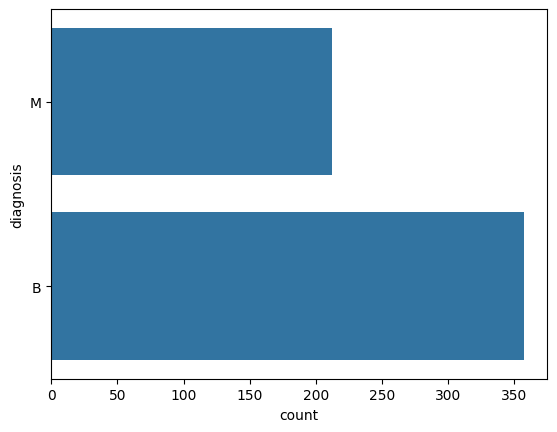

In [11]:
#using seaborn to plot the distribution
sns.countplot(data['diagnosis'], label="Count")

### Encode the target
`M` (malignant) becomes 1 and `B` (benign) becomes 0, so "positive" means malignant in all metrics below.

In [12]:
#encoding the target column
data['diagnosis'] = data['diagnosis'].map({'M':1,'B':0})

In [13]:
data['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

### Features and labels
The `id` column is an identifier with no predictive meaning and is excluded. The remaining 30 columns are the features.

In [14]:
y = data['diagnosis'].values
X = data.drop(columns=['diagnosis','id']).values

### Correlation between features
The heatmap shows the 10 **mean** features and the diagnosis. Size-related features (radius, perimeter, area) are almost perfectly correlated with each other, and several are also strongly correlated with the diagnosis. The models below use all 30 features, not just these 10. Because many features carry overlapping information, individual feature importance should be interpreted with care.

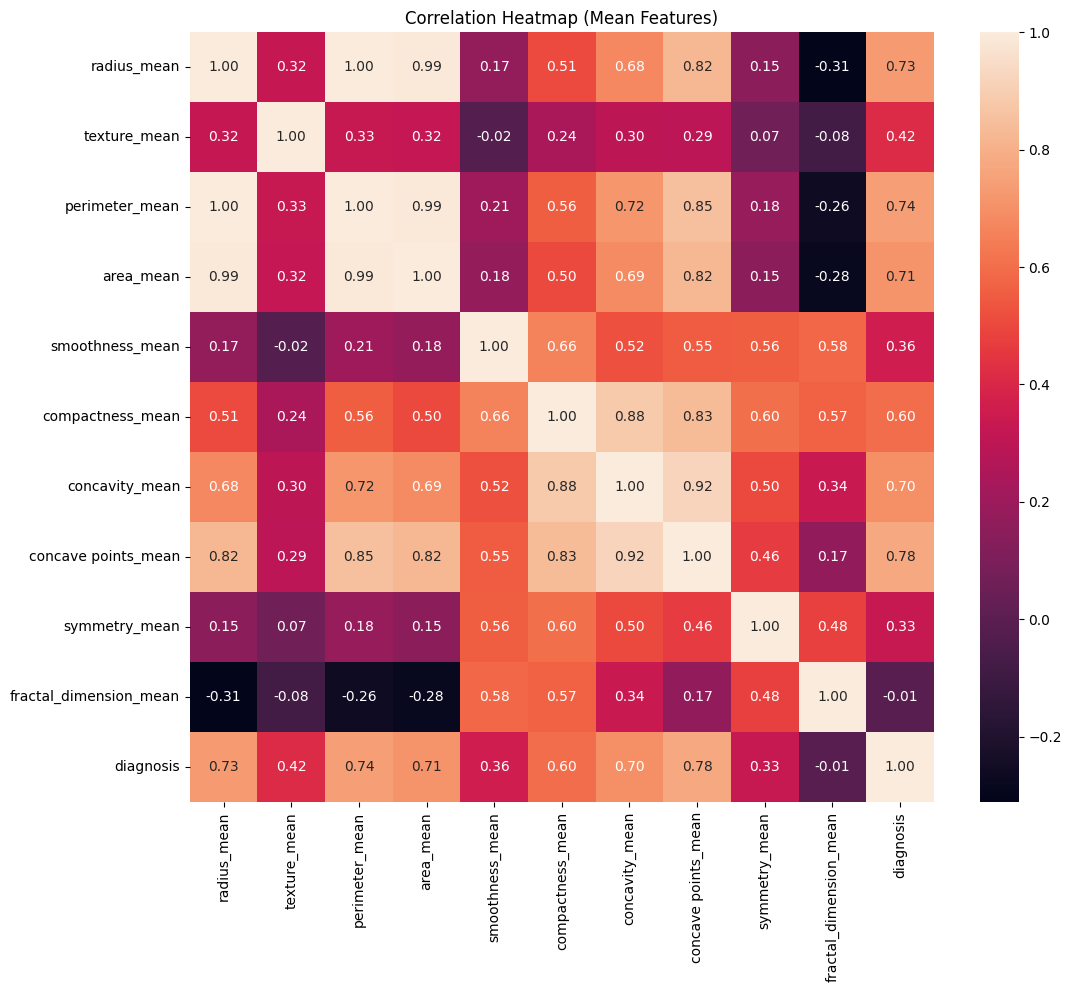

In [15]:
#correlation heatmap
#checking correlation between selected features and the target column
plt.figure(figsize=(12,10))
mean_columns = [col for col in data.columns if 'mean' in col]
correlation = data[mean_columns + ['diagnosis']].corr()
sns.heatmap(correlation, annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Mean Features)")
plt.show()

## 4. Preprocessing
### Train/test split
80% of the data is used for training and 20% for testing (`random_state=42` for reproducibility).

### Feature scaling
Features are standardised (zero mean, unit variance). The scaler is **fitted on the training set only** and then applied to the test set, so no information from the test data leaks into training. Scaling matters for the neural network, SVM and Logistic Regression.

In [16]:
#splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  
print(f'The shape of the training data set is {X_train.shape}, and the shape of the test data set is {X_test.shape}')

The shape of the training data set is (455, 30), and the shape of the test data set is (114, 30)


In [17]:
#normalizing the data using standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled

array([[-1.44075296, -0.43531947, -1.36208497, ...,  0.9320124 ,
         2.09724217,  1.88645014],
       [ 1.97409619,  1.73302577,  2.09167167, ...,  2.6989469 ,
         1.89116053,  2.49783848],
       [-1.39998202, -1.24962228, -1.34520926, ..., -0.97023893,
         0.59760192,  0.0578942 ],
       ...,
       [ 0.04880192, -0.55500086, -0.06512547, ..., -1.23903365,
        -0.70863864, -1.27145475],
       [-0.03896885,  0.10207345, -0.03137406, ...,  1.05001236,
         0.43432185,  1.21336207],
       [-0.54860557,  0.31327591, -0.60350155, ..., -0.61102866,
        -0.3345212 , -0.84628745]], shape=(455, 30))

## 5. Models
### Neural network
A small feed-forward network: 30 inputs → Dense(16, ReLU) → Dropout(0.2) → Dense(1, sigmoid). The sigmoid output is the predicted probability of malignancy. It is trained with binary cross-entropy and the Adam optimiser for 100 epochs with batch size 32. Dropout is used to reduce overfitting on this small dataset.

In [50]:
#using a simple neural network model
nn_model = Sequential()
nn_model.add(Dense(16, input_dim=X_train_scaled.shape[1], activation='relu'))
nn_model.add(Dropout(0.2))
nn_model.add(Dense(1))
nn_model.add(Activation('sigmoid'))
nn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
nn_model.summary()

c:\Users\abdul\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
 #fitting the model
results = nn_model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, verbose=1, validation_data=(X_test_scaled, y_test))   

Epoch 1/100


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3143 - loss: 0.8694 - val_accuracy: 0.4737 - val_loss: 0.7187
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5187 - loss: 0.6910 - val_accuracy: 0.6930 - val_loss: 0.5704
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7033 - loss: 0.5459 - val_accuracy: 0.8158 - val_loss: 0.4723
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7626 - loss: 0.4852 - val_accuracy: 0.8860 - val_loss: 0.4006
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8440 - loss: 0.4103 - val_accuracy: 0.9298 - val_loss: 0.3456
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8659 - loss: 0.3563 - val_accuracy: 0.9474 - val_loss: 0.3039
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8813 - loss: 0.3354 - val_accuracy: 0.9386 - val_loss: 0.2702
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9099 - loss: 0.2895 - val_accuracy: 0.9474 - val_lo

### Classical models
- **Logistic Regression**: linear baseline
- **Random Forest**: ensemble of decision trees
- **SVM**: RBF kernel (the scikit-learn default), with `probability=True` so that predicted probabilities are available for ROC curves

For each model, the predicted probability of the malignant class is stored for the ROC analysis.

In [20]:
# Machine Learning Models
ml_models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM (Probability)": SVC(probability=True, random_state=42)
}

output = {}

print("Training ML models...")
for name, model in ml_models.items():
    model.fit(X_train_scaled, y_train)
    
    # Get predictions
    # predict_proba returns [prob_benign, prob_malignant], we want column 1
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    acc = accuracy_score(y_test, y_pred)
    
    output[name] = {
        "fpr": fpr, 
        "tpr": tpr, 
        "auc": roc_auc, 
        "acc": acc
    }

Training ML models...


## 6. Evaluation
### Neural network predictions
Probabilities from the network are converted to class labels with a 0.5 threshold, then evaluated the same way as the other models.

In [52]:
# Get predictions for NN
y_prob_nn = nn_model.predict(X_test_scaled).ravel() # .ravel() flattens array to 1D
y_pred_nn = (y_prob_nn > 0.5).astype("int32")

# Calculate NN metrics
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
auc_nn = auc(fpr_nn, tpr_nn)
acc_nn = accuracy_score(y_test, y_pred_nn)

# Add NN to results dictionary
output["Neural Network"] = {
    "fpr": fpr_nn, 
    "tpr": tpr_nn, 
    "auc": auc_nn, 
    "acc": acc_nn
}

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


### ROC curves
The ROC curve plots the true positive rate (sensitivity) against the false positive rate across all decision thresholds. A curve closer to the top-left corner and a higher AUC mean better separation of the two classes. The dashed diagonal is random guessing.

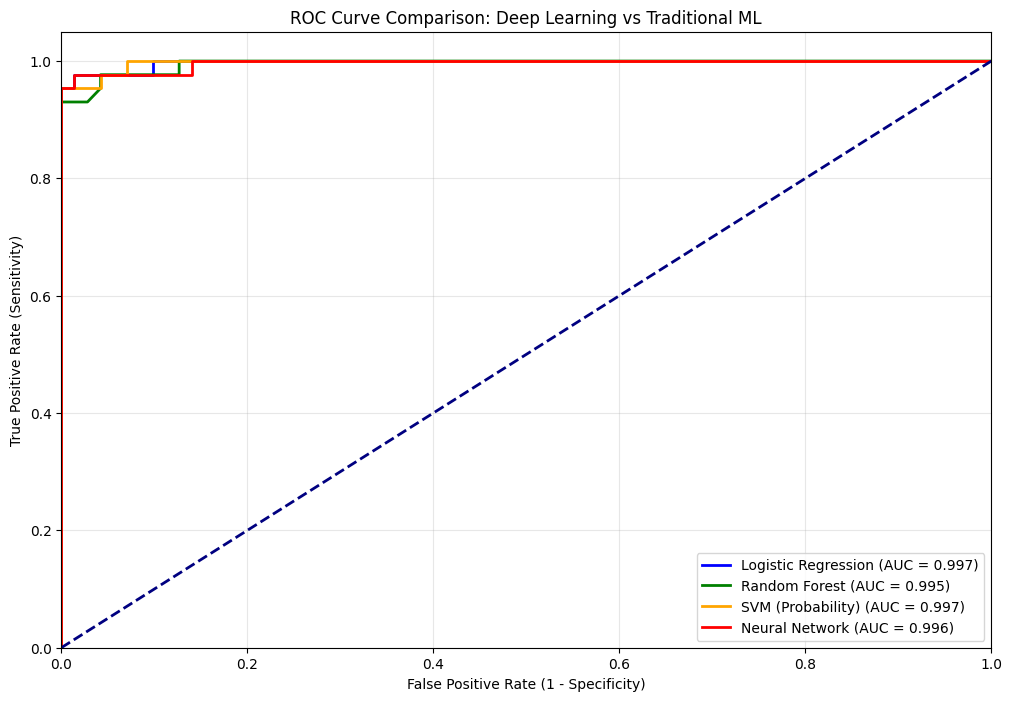

In [53]:
plt.figure(figsize=(12, 8))

colors = ['blue', 'green', 'orange', 'red']

# Loop through the results to plot each curve
for (name, res), color in zip(output.items(), colors):
    plt.plot(res['fpr'], res['tpr'], color=color, lw=2, 
             label=f'{name} (AUC = {res["auc"]:.3f})')

# Plot the "Random Guess" line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Styling
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve Comparison: Deep Learning vs Traditional ML')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.show()

### Neural network learning curves
Accuracy and loss over the 100 training epochs. Training and validation curves that stay close together suggest the model is not badly overfitting.

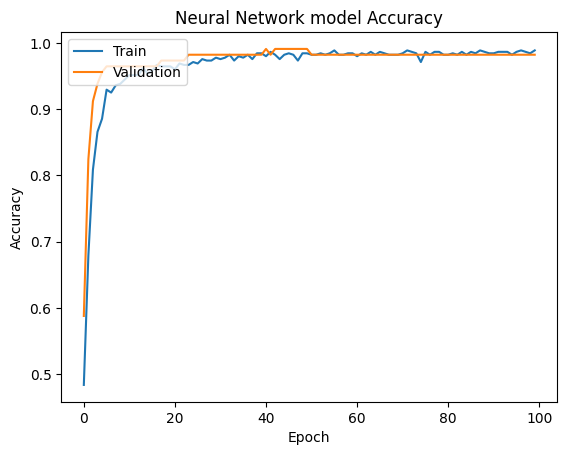

In [23]:
#plotting the training and validation accuracy
plt.plot(results.history['accuracy'])
plt.plot(results.history['val_accuracy'])
plt.title('Neural Network model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

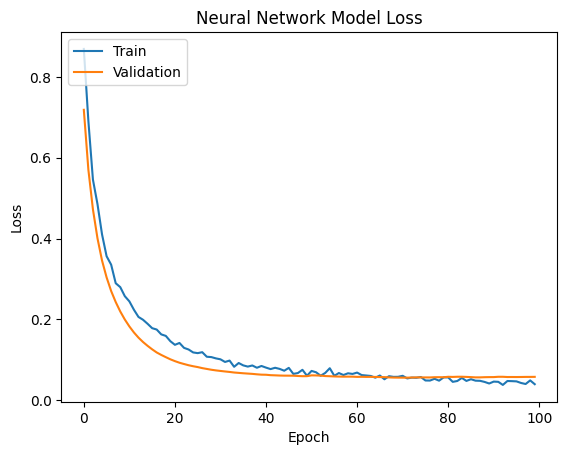

In [54]:
#plotting the training and validation loss
plt.plot(results.history['loss'])
plt.plot(results.history['val_loss'])
plt.title('Neural Network Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### Accuracy comparison
The test set contains 114 samples, so one extra misclassification changes accuracy by roughly 0.9 percentage points. Small differences between models should not be over-interpreted.

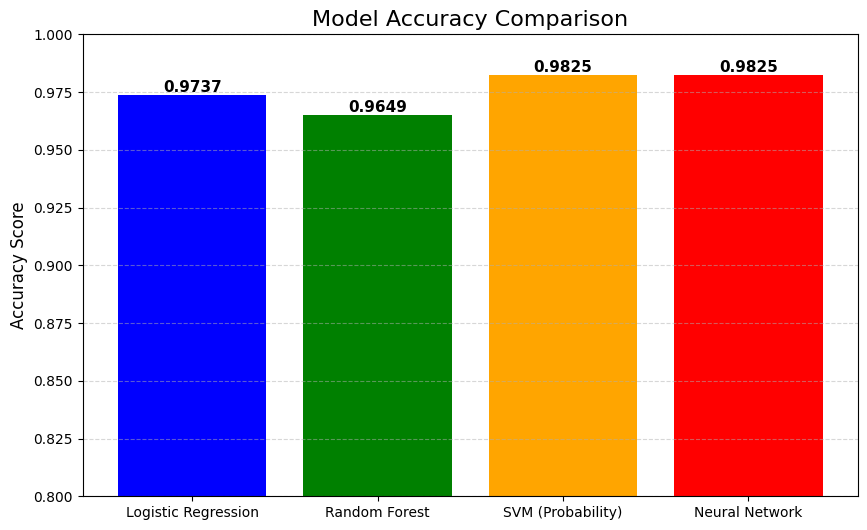

In [25]:
# Create a new figure for the bar chart
plt.figure(figsize=(10, 6))

# Extract names and accuracy scores from the 'output' dictionary
model_names = list(output.keys())
accuracy_scores = [output[name]['acc'] for name in model_names]

# Define colors for the bars
colors = ['blue', 'green', 'orange', 'red']

# Create the bar chart
bars = plt.bar(model_names, accuracy_scores, color=colors)

# Styling
plt.title('Model Accuracy Comparison', fontsize=16)
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0.8, 1.0) # Zoom in to see the differences (since all are likely > 90%)

# Add the actual numbers on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [26]:
# !pip install jinja2

### Full metrics comparison
- **Precision**: of the tumours predicted malignant, how many truly are
- **Recall (sensitivity)**: of the truly malignant tumours, how many were found
- **F1**: harmonic mean of precision and recall
- **ROC AUC**: ranking quality across all thresholds

In a screening setting, a missed malignant case (false negative) is usually more costly than a false alarm, so **recall** deserves particular attention.

In [55]:
# Initialize a list to store our results
model_performance = []

# --- 1. Evaluate Traditional Models ---
for name, model in ml_models.items():
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] # Probability for ROC AUC
    
    # Calculate metrics
    model_performance.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    })

# --- 2. Evaluate Neural Network ---
# (Using the predictions y_pred_nn and probabilities y_prob_nn from previous step)
model_performance.append({
    "Model": "Neural Network",
    "Accuracy": accuracy_score(y_test, y_pred_nn),
    "Precision": precision_score(y_test, y_pred_nn),
    "Recall": recall_score(y_test, y_pred_nn),
    "F1-Score": f1_score(y_test, y_pred_nn),
    "ROC AUC": roc_auc_score(y_test, y_prob_nn)
})

# --- 3. Create and View DataFrame ---
metrics_df = pd.DataFrame(model_performance)

# Optional: Format the floats to look cleaner (2 decimal places)
# This changes the values to strings for display
metrics_df_styled = metrics_df.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-Score": "{:.2%}",
    "ROC AUC": "{:.4f}"
}).background_gradient(cmap='coolwarm', subset=["Accuracy", "Recall", "ROC AUC"])

metrics_df_styled

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,Logistic Regression,97.37%,97.62%,95.35%,96.47%,0.9974
1,Random Forest,96.49%,97.56%,93.02%,95.24%,0.9953
2,SVM (Probability),98.25%,100.00%,95.35%,97.62%,0.9974
3,Neural Network,98.25%,97.67%,97.67%,97.67%,0.9964


## 7. Explainability with SHAP
SHAP assigns each feature a contribution to each individual prediction. In the summary plots below, each dot is one test sample: its horizontal position is the feature's impact on the predicted probability of malignancy (right = pushes towards malignant, left = towards benign), and its colour is the feature's value (red = high, blue = low). Features are ordered by overall importance.

In [36]:
# #Extracting the random forest model for explainability
# rf_model = ml_models["Random Forest"]
# # Initialize the explainer with your trained Random Forest model
# explainer = shap.TreeExplainer(rf_model) # rf_model is the Random Forest from the previous step
# shap_values = explainer.shap_values(X_test_scaled)

# # 1. Summary Plot (Global Interpretability)
# # This shows which features matter most.
# # - Red dots = High values of the feature
# # - Blue dots = Low values of the feature
# # - Right side = Pushes prediction towards "Malignant" (1)
# plt.figure(figsize=(10, 8))
# shap.summary_plot(shap_values[1][:, :-1], X_test_scaled, plot_type="dot")

In [58]:
features = data.columns.tolist()
features_name = features[2:]
features_name

['radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst']

### SHAP: neural network
Uses `DeepExplainer` with 100 training samples as background, explaining the first 100 test samples.

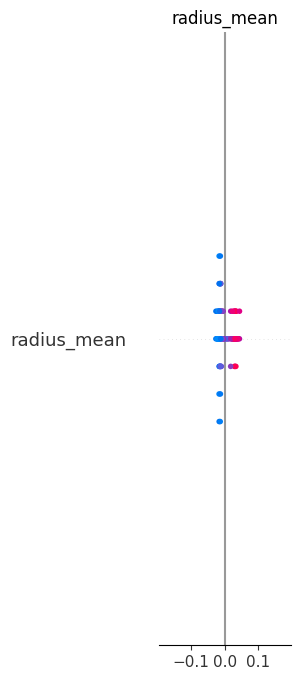

In [61]:
# For the Neural Network (assuming 'model' is your Keras model)
# We use a background dataset (X_train) to simulate "average" inputs
background = X_train_scaled[:100] # summarizing the first 100 samples
e = shap.DeepExplainer(nn_model, background)
shap_values_dl = e.shap_values(X_test_scaled[:100]) # explaining first 10 test samples
# Plot
shap.summary_plot(shap_values_dl, X_test_scaled[:100], feature_names=features_name)

### SHAP: SVM
Uses `KernelExplainer`, which is model-agnostic but slow, so the training set is summarised with 10 k-means centroids as the background. The explanation is for the malignant-class probability.

100%|██████████| 114/114 [00:43<00:00,  2.61it/s]


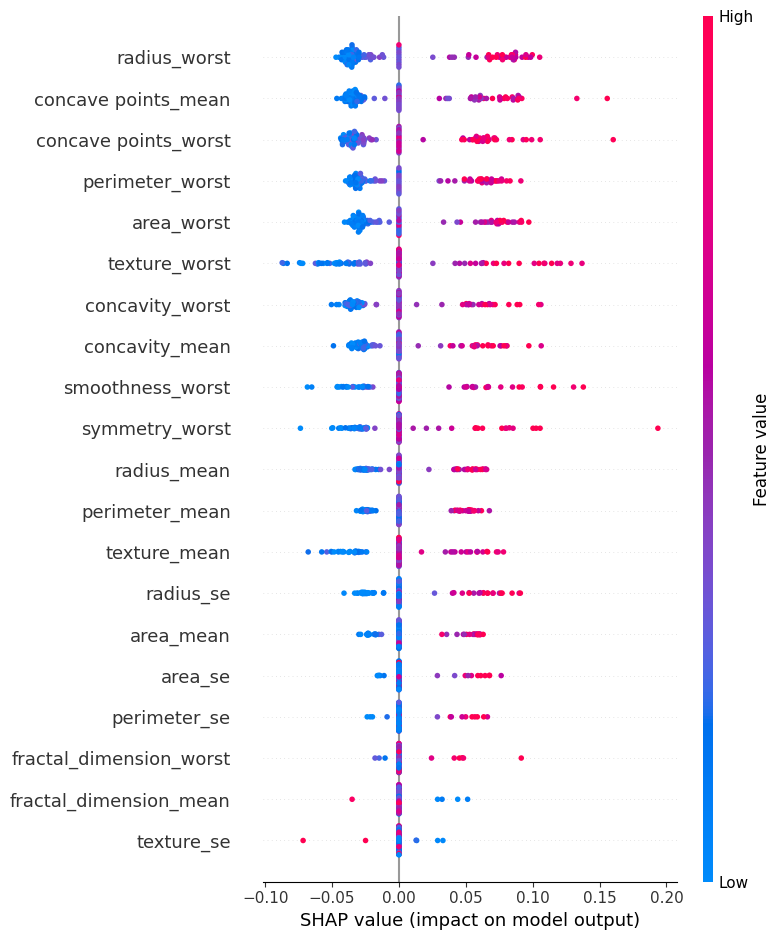

In [48]:

svm_model = ml_models['SVM (Probability)']
# 1. Summarize the background data
# KernelExplainer is slow, so we use a small summary (e.g., K-Means or just a random sample)
# to represent the "average" patient.
X_train_summary = shap.kmeans(X_train_scaled, 10) 

# 2. Create the Explainer
# We pass the predict_proba function so we get probability outputs
#explainer_svm = shap.KernelExplainer(ml_models['SVM (Probability)'].predict_proba, X_train_summary)
explainer_svm = shap.KernelExplainer(
    svm_model.predict_proba,
    X_train_summary
)
# 3. Calculate SHAP values for the test set
# Warning: This step can be slow! We limit to fewer samples if needed.
shap_values_svm = explainer_svm.shap_values(X_test_scaled)

shap_vals_malignant = shap_values_svm[:, :, 1]

# 4. Plot
# shap_values_svm is a list [benign_values, malignant_values]. We usually plot index 1 (Malignant).
shap.summary_plot(
    shap_vals_malignant,
    X_test_scaled,
    feature_names=features_name
)

### Reading the SVM SHAP plot
The most influential features are the "worst" (largest-value) measurements and the concavity-related features: `radius_worst`, `concave points_mean`, `concave points_worst`, `perimeter_worst`, `area_worst`, `texture_worst` and `concavity_worst`. For these, high feature values (red) push the prediction towards malignant, and low values (blue) push it towards benign. This is consistent with the clinical intuition that larger, more irregular nuclei are associated with malignancy.

## 8. Conclusions and limitations
### Conclusions
- All four models separate malignant from benign tumours very well on this dataset.
- Differences between the models are within a few test samples, so this notebook does not show that any one model is better than the others.
- SHAP highlights size and concavity-related features as the main drivers of the predictions.

### Possible extensions
- Stratified k-fold cross-validation with mean and standard deviation per model
- Confusion matrices and threshold selection that favours recall
- Hyperparameter tuning and early stopping
- Comparing results with a reduced, less correlated feature set

**Source:** Wolberg, W.H., Street, W.N., Mangasarian, O.L. *Breast Cancer Wisconsin (Diagnostic)*. UCI Machine Learning Repository.